# SMART CROP YIELD PREDICTION USING MACHINE LEARNING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#load dataset
df=pd.read_csv("smart crop yield.csv")

In [3]:
#display dataset
df.head()

,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours,Yield_ton_per_hectare
0,Andhra Pradesh,Rice,Kharif,Alluvial,Canal,BPT-5204,Conventional,Normal,Low,1200.0,850.0,28.5,78.0,6.5,32.0,180.0,12.0,420.0,7.2,4.2
1,Telangana,Cotton,Kharif,Black,Drip,Bt-Cotton,Organic,Sunny,Medium,950.0,720.0,29.2,70.0,7.1,28.0,160.0,10.0,350.0,8.1,2.8
2,Maharashtra,Wheat,Rabi,Black,Drip,Lok-1,Conventional,Cloudy,Low,1100.0,680.0,25.4,62.0,6.8,25.0,175.0,9.0,300.0,7.8,3.5
3,Punjab,Rice,Kharif,Alluvial,Canal,PR-126,Conventional,Rainy,Low,1350.0,920.0,27.8,81.0,6.7,35.0,190.0,13.0,450.0,6.9,4.6
4,Karnataka,Maize,Kharif,Red,Sprinkler,NK-6240,Organic,Normal,Medium,1000.0,760.0,26.7,68.0,6.2,30.0,155.0,8.0,380.0,7.5,3.8


In [4]:
df.tail()

,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours,Yield_ton_per_hectare
8,West Bengal,Potato,Rabi,Loamy,Sprinkler,Kufri-Jyoti,Conventional,Cloudy,Medium,800.0,1050.0,23.9,76.0,6.1,34.0,170.0,10.0,360.0,6.8,4.1
9,Rajasthan,Bajra,Kharif,Sandy,Rainfed,HHB-67,Organic,Sunny,High,1050.0,480.0,31.5,48.0,7.5,18.0,135.0,6.0,180.0,9.0,2.2
10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(13, 20)

In [6]:
df.columns

Index(['State', 'Crop', 'Season', 'Soil_Type', 'Irrigation_Type',
       'Seed_Variety', 'Farming_Method', 'Weather_Condition',
       'Crop_Disease_Status', 'Area_Hectare', 'Rainfall_mm', 'Temperature_C',
       'Humidity_%', 'Soil_pH', 'Soil_Moisture_%', 'Fertilizer_kg',
       'Pesticide_kg', 'Irrigation_Water_mm', 'Sunshine_Hours',
       'Yield_ton_per_hectare'],
      dtype='object')

In [7]:
df.shape

(13, 20)

In [8]:
df.dtypes

State                     object
Crop                      object
Season                    object
Soil_Type                 object
Irrigation_Type           object
Seed_Variety              object
Farming_Method            object
Weather_Condition         object
Crop_Disease_Status       object
Area_Hectare             float64
Rainfall_mm              float64
Temperature_C            float64
Humidity_%               float64
Soil_pH                  float64
Soil_Moisture_%          float64
Fertilizer_kg            float64
Pesticide_kg             float64
Irrigation_Water_mm      float64
Sunshine_Hours           float64
Yield_ton_per_hectare    float64
dtype: object

In [9]:
df.axes

[RangeIndex(start=0, stop=13, step=1),
 Index(['State', 'Crop', 'Season', 'Soil_Type', 'Irrigation_Type',
        'Seed_Variety', 'Farming_Method', 'Weather_Condition',
        'Crop_Disease_Status', 'Area_Hectare', 'Rainfall_mm', 'Temperature_C',
        'Humidity_%', 'Soil_pH', 'Soil_Moisture_%', 'Fertilizer_kg',
        'Pesticide_kg', 'Irrigation_Water_mm', 'Sunshine_Hours',
        'Yield_ton_per_hectare'],
       dtype='object')]

In [10]:
df.values

array([['Andhra Pradesh', 'Rice', 'Kharif', 'Alluvial', 'Canal',
        'BPT-5204', 'Conventional', 'Normal', 'Low', 1200.0, 850.0, 28.5,
        78.0, 6.5, 32.0, 180.0, 12.0, 420.0, 7.2, 4.2],
       ['Telangana', 'Cotton', 'Kharif', 'Black', 'Drip', 'Bt-Cotton',
        'Organic', 'Sunny', 'Medium', 950.0, 720.0, 29.2, 70.0, 7.1,
        28.0, 160.0, 10.0, 350.0, 8.1, 2.8],
       ['Maharashtra', 'Wheat', 'Rabi', 'Black', 'Drip', 'Lok-1',
        'Conventional', 'Cloudy', 'Low', 1100.0, 680.0, 25.4, 62.0, 6.8,
        25.0, 175.0, 9.0, 300.0, 7.8, 3.5],
       ['Punjab', 'Rice', 'Kharif', 'Alluvial', 'Canal', 'PR-126',
        'Conventional', 'Rainy', 'Low', 1350.0, 920.0, 27.8, 81.0, 6.7,
        35.0, 190.0, 13.0, 450.0, 6.9, 4.6],
       ['Karnataka', 'Maize', 'Kharif', 'Red', 'Sprinkler', 'NK-6240',
        'Organic', 'Normal', 'Medium', 1000.0, 760.0, 26.7, 68.0, 6.2,
        30.0, 155.0, 8.0, 380.0, 7.5, 3.8],
       ['Uttar Pradesh', 'Wheat', 'Rabi', 'Alluvial', 'Tube_Well',


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   State                  10 non-null     object 
 1   Crop                   10 non-null     object 
 2   Season                 10 non-null     object 
 3   Soil_Type              10 non-null     object 
 4   Irrigation_Type        10 non-null     object 
 5   Seed_Variety           10 non-null     object 
 6   Farming_Method         10 non-null     object 
 7   Weather_Condition      10 non-null     object 
 8   Crop_Disease_Status    11 non-null     object 
 9   Area_Hectare           10 non-null     float64
 10  Rainfall_mm            10 non-null     float64
 11  Temperature_C          10 non-null     float64
 12  Humidity_%             10 non-null     float64
 13  Soil_pH                10 non-null     float64
 14  Soil_Moisture_%        10 non-null     float64
 15  Fertiliz

In [12]:
df.describe()

,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours,Yield_ton_per_hectare
count,10.000000,10.0000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.00000
mean,1100.000000,769.0000,27.690000,69.100000,6.760000,28.600000,169.000000,10.000000,352.000000,7.58000,3.62000
std,197.202659,179.0996,2.447879,11.090036,0.467143,6.345602,19.832633,2.581989,85.738621,0.77431,0.87661
min,800.000000,480.0000,23.900000,48.000000,6.100000,18.000000,135.000000,6.000000,180.000000,6.50000,2.20000
25%,962.500000,650.0000,25.725000,62.750000,6.425000,24.250000,156.250000,8.250000,305.000000,6.97500,2.97500
50%,1075.000000,740.0000,28.150000,69.000000,6.750000,29.000000,172.500000,10.000000,355.000000,7.55000,3.75000
75%,1237.500000,902.5000,29.150000,77.500000,7.075000,33.500000,183.750000,11.750000,410.000000,8.02500,4.17500
max,1400.000000,1050.0000,31.500000,84.000000,7.500000,38.000000,195.000000,14.000000,470.000000,9.00000,4.80000


In [13]:
df.columns.tolist()

['State',
 'Crop',
 'Season',
 'Soil_Type',
 'Irrigation_Type',
 'Seed_Variety',
 'Farming_Method',
 'Weather_Condition',
 'Crop_Disease_Status',
 'Area_Hectare',
 'Rainfall_mm',
 'Temperature_C',
 'Humidity_%',
 'Soil_pH',
 'Soil_Moisture_%',
 'Fertilizer_kg',
 'Pesticide_kg',
 'Irrigation_Water_mm',
 'Sunshine_Hours',
 'Yield_ton_per_hectare']

In [14]:
df.dropna()

,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours,Yield_ton_per_hectare
0,Andhra Pradesh,Rice,Kharif,Alluvial,Canal,BPT-5204,Conventional,Normal,Low,1200.0,850.0,28.5,78.0,6.5,32.0,180.0,12.0,420.0,7.2,4.2
1,Telangana,Cotton,Kharif,Black,Drip,Bt-Cotton,Organic,Sunny,Medium,950.0,720.0,29.2,70.0,7.1,28.0,160.0,10.0,350.0,8.1,2.8
2,Maharashtra,Wheat,Rabi,Black,Drip,Lok-1,Conventional,Cloudy,Low,1100.0,680.0,25.4,62.0,6.8,25.0,175.0,9.0,300.0,7.8,3.5
3,Punjab,Rice,Kharif,Alluvial,Canal,PR-126,Conventional,Rainy,Low,1350.0,920.0,27.8,81.0,6.7,35.0,190.0,13.0,450.0,6.9,4.6
4,Karnataka,Maize,Kharif,Red,Sprinkler,NK-6240,Organic,Normal,Medium,1000.0,760.0,26.7,68.0,6.2,30.0,155.0,8.0,380.0,7.5,3.8
5,Uttar Pradesh,Wheat,Rabi,Alluvial,Tube_Well,HD-2967,Conventional,Sunny,Low,1400.0,640.0,24.8,59.0,7.0,24.0,185.0,11.0,320.0,7.6,3.7
6,Tamil Nadu,Rice,Kharif,Clay,Canal,CO-51,Organic,Rainy,Low,1250.0,980.0,29.0,84.0,6.4,38.0,195.0,14.0,470.0,6.5,4.8
7,Gujarat,Groundnut,Kharif,Sandy,Drip,GG-20,Conventional,Sunny,High,900.0,610.0,30.1,65.0,7.3,22.0,145.0,7.0,290.0,8.4,2.5
8,West Bengal,Potato,Rabi,Loamy,Sprinkler,Kufri-Jyoti,Conventional,Cloudy,Medium,800.0,1050.0,23.9,76.0,6.1,34.0,170.0,10.0,360.0,6.8,4.1
9,Rajasthan,Bajra,Kharif,Sandy,Rainfed,HHB-67,Organic,Sunny,High,1050.0,480.0,31.5,48.0,7.5,18.0,135.0,6.0,180.0,9.0,2.2


In [15]:
df.isnull().sum()

State                    3
Crop                     3
Season                   3
Soil_Type                3
Irrigation_Type          3
Seed_Variety             3
Farming_Method           3
Weather_Condition        3
Crop_Disease_Status      2
Area_Hectare             3
Rainfall_mm              3
Temperature_C            3
Humidity_%               3
Soil_pH                  3
Soil_Moisture_%          3
Fertilizer_kg            3
Pesticide_kg             3
Irrigation_Water_mm      3
Sunshine_Hours           3
Yield_ton_per_hectare    3
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(1)

# BIVARIATE ANALYSIS

In [17]:
df['Yield_ton_per_hectare'] = pd.to_numeric(
   df['Yield_ton_per_hectare'], errors='coerce'
)

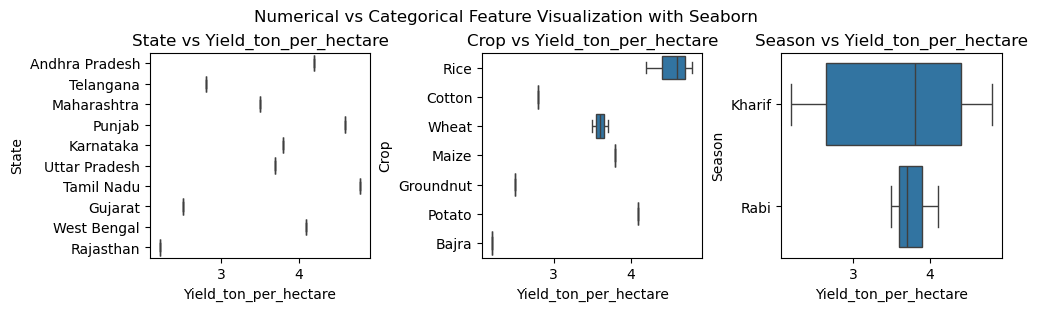

In [18]:
# Bivariate - Categorical vs Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
fig.suptitle("Numerical vs Categorical Feature Visualization with Seaborn")

axs[0].set_title("State vs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='State', ax=axs[0])

axs[1].set_title("Crop vs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Crop', ax=axs[1])

axs[2].set_title("Season vs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Season', ax=axs[2])

plt.show()

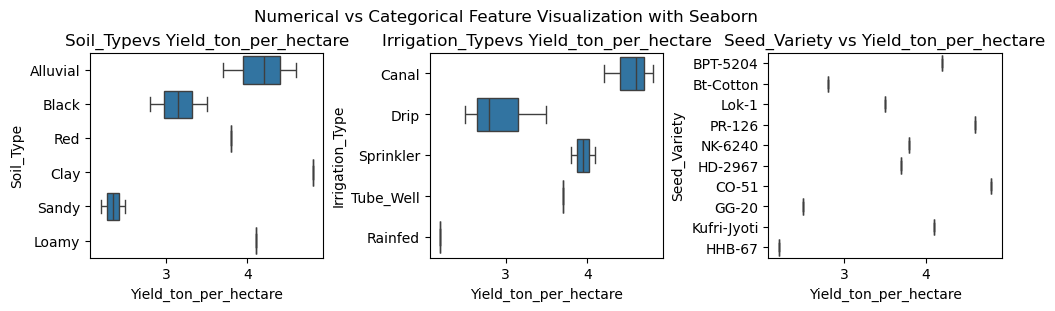

In [19]:
# Bivariate - Categorical vs Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
fig.suptitle("Numerical vs Categorical Feature Visualization with Seaborn")

axs[0].set_title("Soil_Typevs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Soil_Type', ax=axs[0])

axs[1].set_title("Irrigation_Typevs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Irrigation_Type', ax=axs[1])

axs[2].set_title("Seed_Variety vs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Seed_Variety', ax=axs[2])

plt.show()

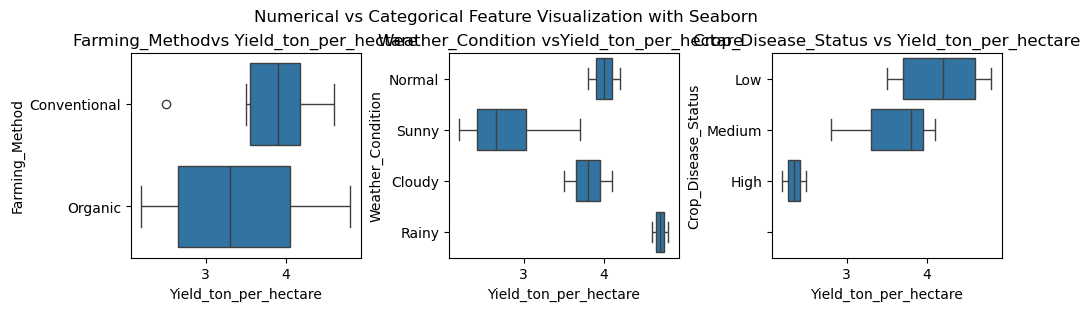

In [20]:
# Bivariate - Categorical vs Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True)
fig.suptitle("Numerical vs Categorical Feature Visualization with Seaborn")

axs[0].set_title("Farming_Methodvs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Farming_Method', ax=axs[0])

axs[1].set_title("Weather_Condition vsYield_ton_per_hectare ")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Weather_Condition', ax=axs[1])

axs[2].set_title("Crop_Disease_Status vs Yield_ton_per_hectare")
sns.boxplot(data=df, x='Yield_ton_per_hectare', y='Crop_Disease_Status', ax=axs[2])

plt.show()

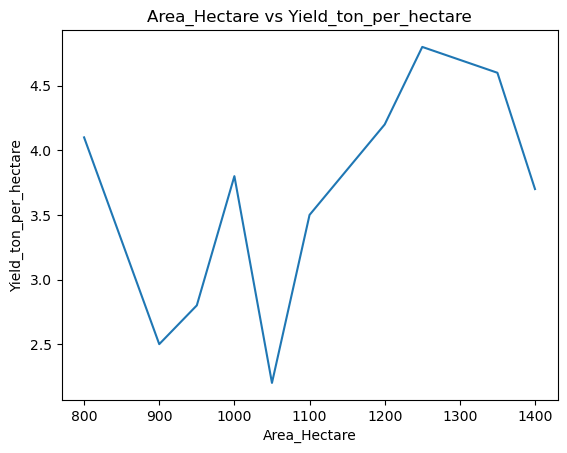

In [21]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Area_Hectare", y="Yield_ton_per_hectare")

plt.title("Area_Hectare vs Yield_ton_per_hectare")
plt.xlabel("Area_Hectare")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

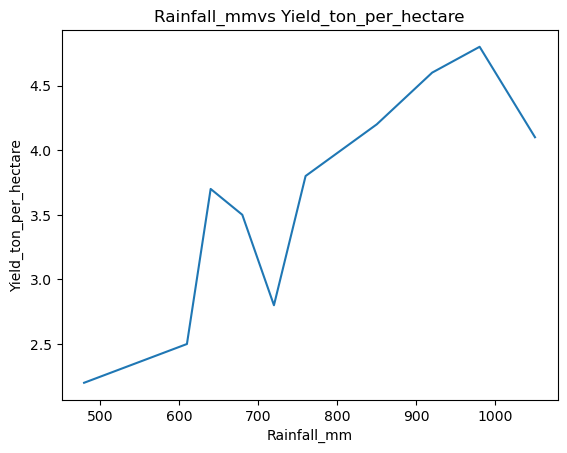

In [22]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Rainfall_mm", y="Yield_ton_per_hectare")

plt.title("Rainfall_mmvs Yield_ton_per_hectare")
plt.xlabel("Rainfall_mm")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

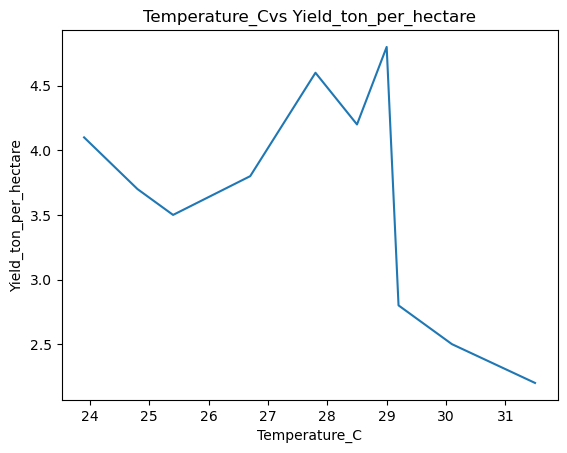

In [23]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Temperature_C", y="Yield_ton_per_hectare")

plt.title("Temperature_Cvs Yield_ton_per_hectare")
plt.xlabel("Temperature_C")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

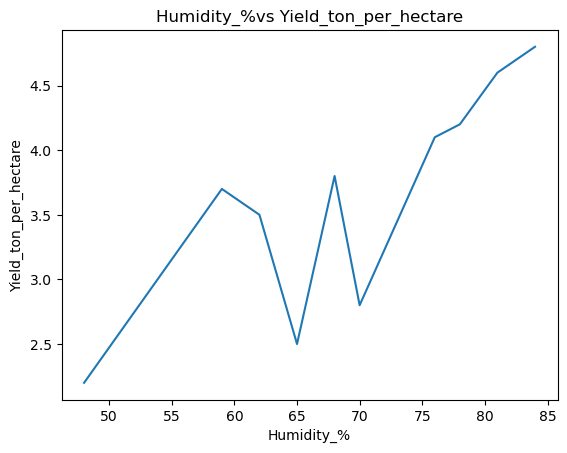

In [24]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Humidity_%", y="Yield_ton_per_hectare")

plt.title("Humidity_%vs Yield_ton_per_hectare")
plt.xlabel("Humidity_%")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

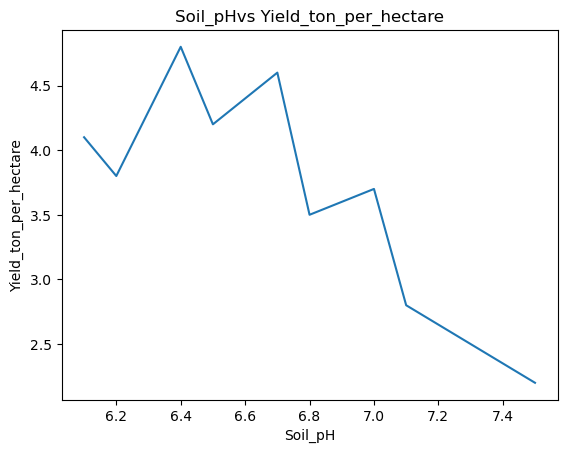

In [25]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Soil_pH", y="Yield_ton_per_hectare")

plt.title("Soil_pHvs Yield_ton_per_hectare")
plt.xlabel("Soil_pH")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

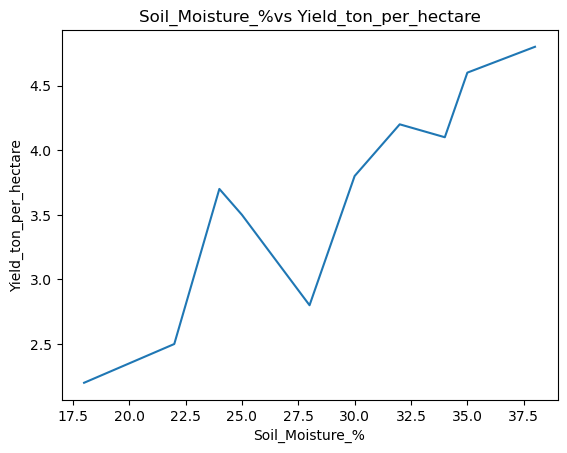

In [26]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Soil_Moisture_%", y="Yield_ton_per_hectare")

plt.title("Soil_Moisture_%vs Yield_ton_per_hectare")
plt.xlabel("Soil_Moisture_%")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

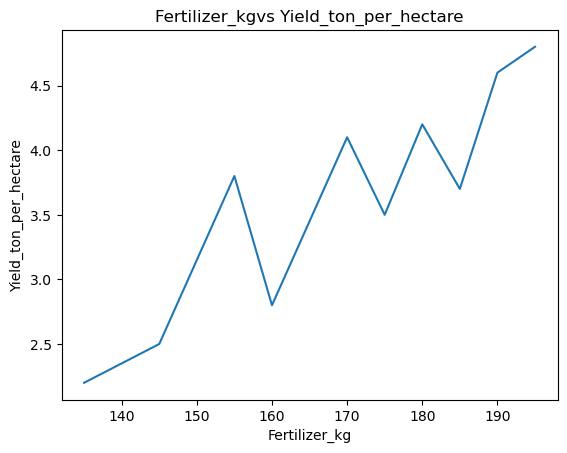

In [27]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Fertilizer_kg", y="Yield_ton_per_hectare")

plt.title("Fertilizer_kgvs Yield_ton_per_hectare")
plt.xlabel("Fertilizer_kg")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

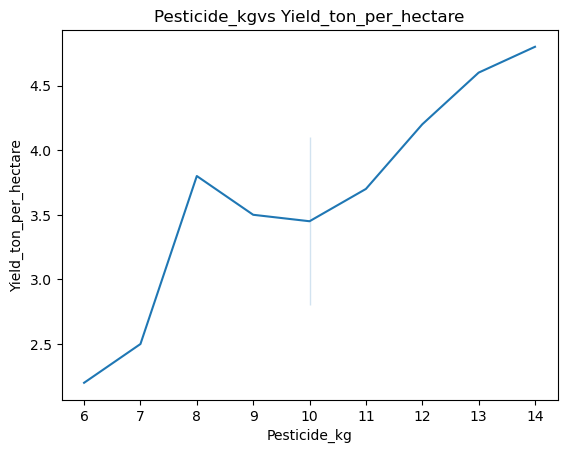

In [28]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Pesticide_kg", y="Yield_ton_per_hectare")

plt.title("Pesticide_kgvs Yield_ton_per_hectare")
plt.xlabel("Pesticide_kg")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

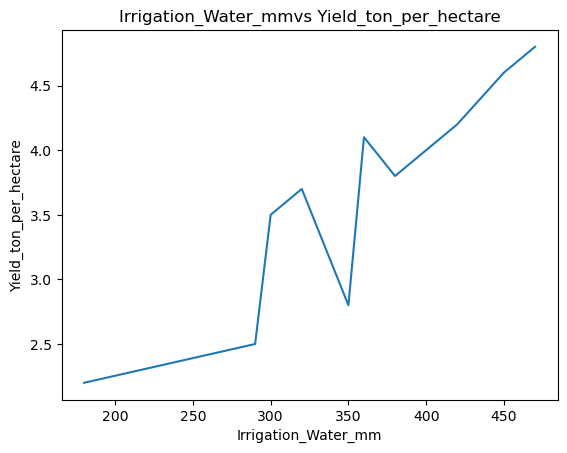

In [29]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Irrigation_Water_mm", y="Yield_ton_per_hectare")

plt.title("Irrigation_Water_mmvs Yield_ton_per_hectare")
plt.xlabel("Irrigation_Water_mm")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

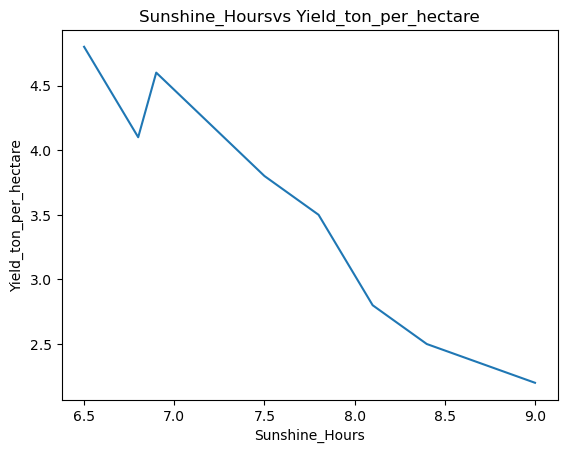

In [30]:
#numerical vs numerical(lineplot)
sns.lineplot(data=df, x="Sunshine_Hours", y="Yield_ton_per_hectare")

plt.title("Sunshine_Hoursvs Yield_ton_per_hectare")
plt.xlabel("Sunshine_Hours")
plt.ylabel("Yield_ton_per_hectare")
plt.show()

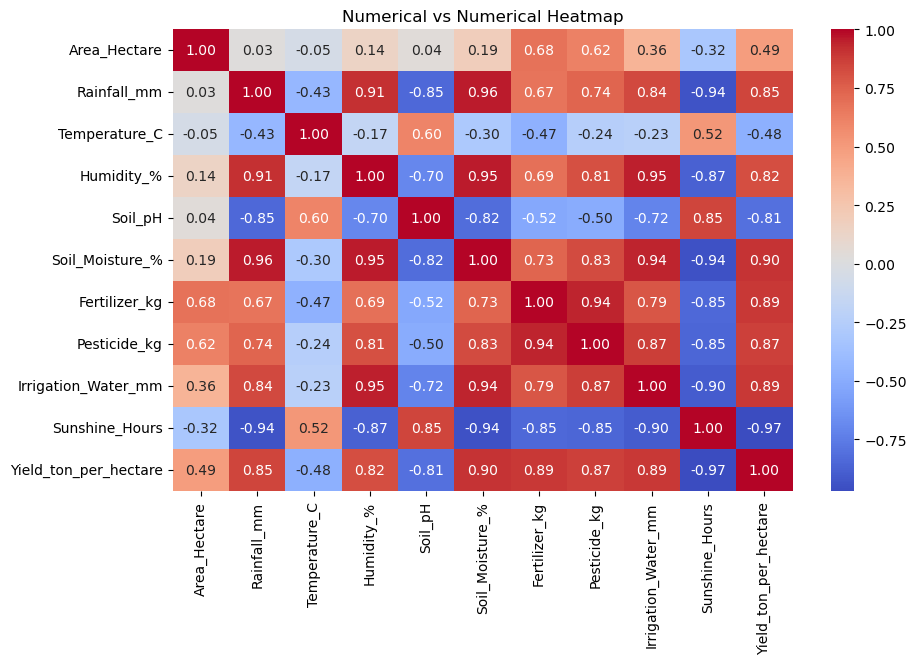

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\diris\Downloads\smart crop yield.csv")

# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Calculate correlation
corr = numeric_df.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Numerical vs Numerical Heatmap")
plt.show()

# UNIVARIATE ANALYSIS

<Axes: title={'center': 'Temperature_C'}, xlabel='Temperature_C', ylabel='Count'>

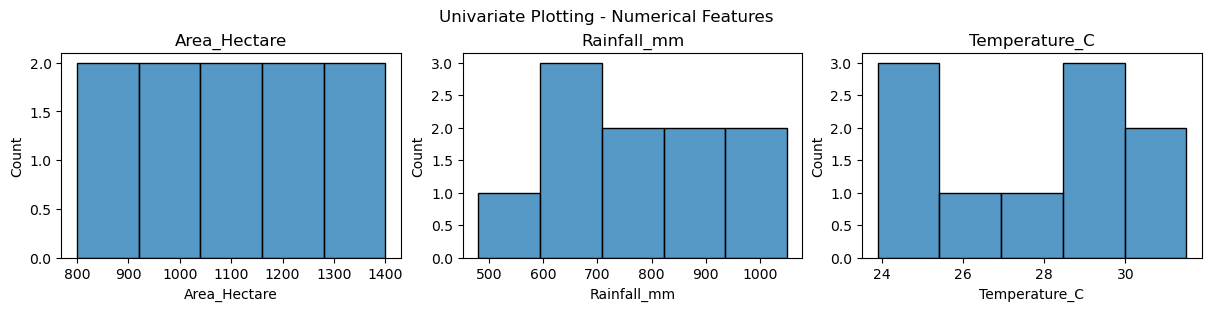

In [33]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Area_Hectare")
sns.histplot(data=df, x='Area_Hectare', ax=axs[0])

axs[1].set_title("Rainfall_mm")
sns.histplot(data=df, x='Rainfall_mm', ax=axs[1])

axs[2].set_title("Temperature_C")
sns.histplot(data=df, x='Temperature_C', ax=axs[2])

<Axes: title={'center': 'Soil_Moisture_%'}, xlabel='Soil_Moisture_%', ylabel='Count'>

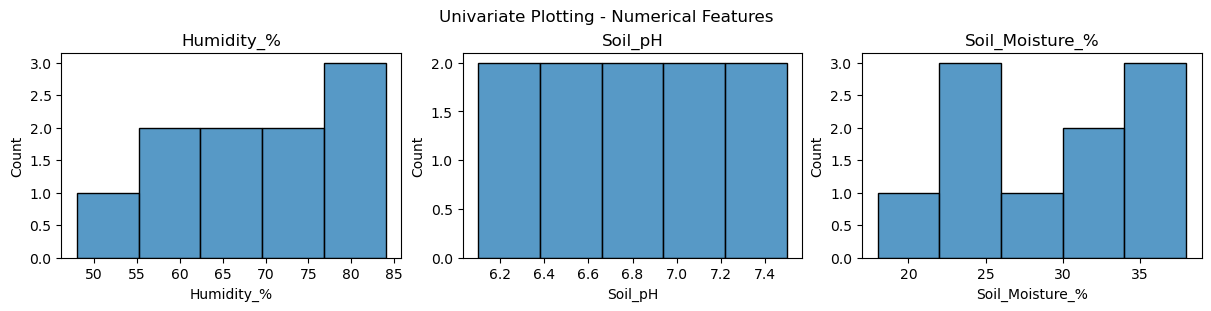

In [34]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Humidity_%")
sns.histplot(data=df, x='Humidity_%', ax=axs[0])

axs[1].set_title("Soil_pH")
sns.histplot(data=df, x='Soil_pH', ax=axs[1])

axs[2].set_title("Soil_Moisture_%")
sns.histplot(data=df, x='Soil_Moisture_%', ax=axs[2])

<Axes: title={'center': 'Sunshine_Hours'}, xlabel='Sunshine_Hours', ylabel='Count'>

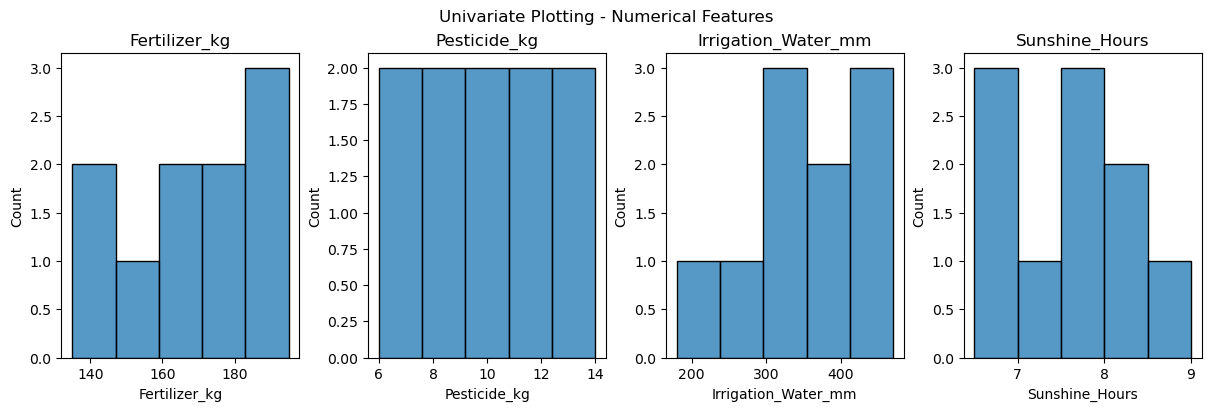

In [35]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 4, figsize=(12, 4), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Fertilizer_kg")
sns.histplot(data=df, x='Fertilizer_kg', ax=axs[0])

axs[1].set_title("Pesticide_kg")
sns.histplot(data=df, x='Pesticide_kg', ax=axs[1])

axs[2].set_title("Irrigation_Water_mm")
sns.histplot(data=df, x='Irrigation_Water_mm', ax=axs[2])

axs[3].set_title("Sunshine_Hours")
sns.histplot(data=df, x='Sunshine_Hours', ax=axs[3])



<Axes: title={'center': 'Temperature_C'}, xlabel='Temperature_C'>

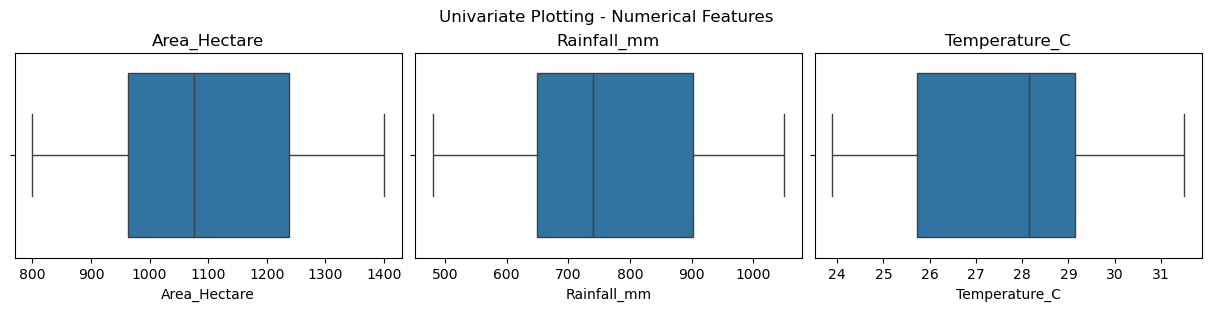

In [36]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Area_Hectare")
sns.boxplot(data=df, x='Area_Hectare', ax=axs[0])

axs[1].set_title("Rainfall_mm")
sns.boxplot(data=df, x='Rainfall_mm', ax=axs[1])

axs[2].set_title("Temperature_C")
sns.boxplot(data=df, x='Temperature_C', ax=axs[2])

<Axes: title={'center': 'Soil_Moisture_%'}, xlabel='Soil_Moisture_%'>

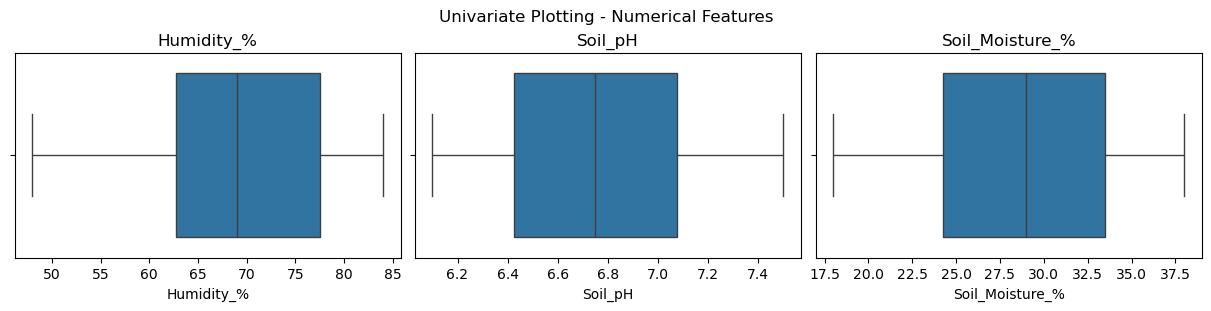

In [37]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Humidity_%")
sns.boxplot(data=df, x='Humidity_%', ax=axs[0])

axs[1].set_title("Soil_pH")
sns.boxplot(data=df, x='Soil_pH', ax=axs[1])

axs[2].set_title("Soil_Moisture_%")
sns.boxplot(data=df, x='Soil_Moisture_%', ax=axs[2])

<Axes: title={'center': 'Sunshine_Hours'}, xlabel='Sunshine_Hours'>

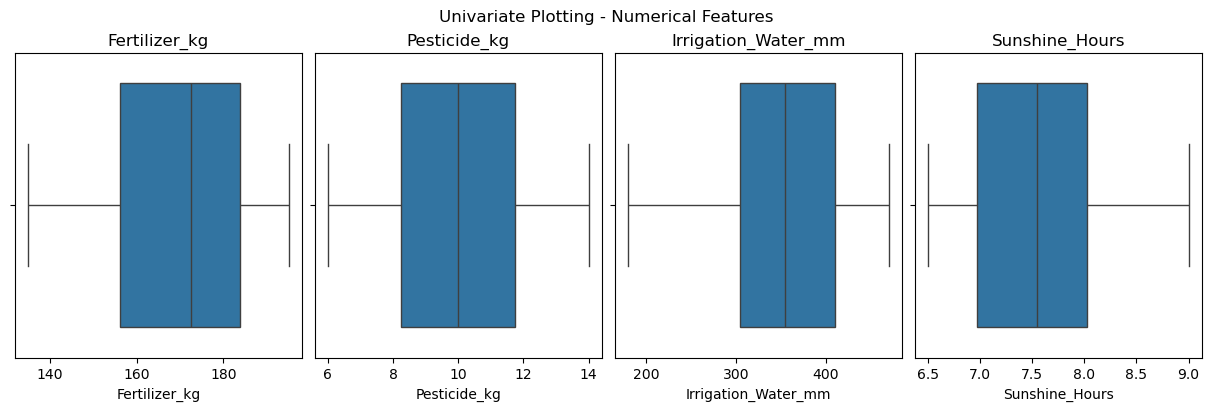

In [38]:
# Univariate - Numerical Analysis

fig, axs = plt.subplots(1, 4, figsize=(12, 4), constrained_layout=True)
fig.suptitle("Univariate Plotting - Numerical Features")

axs[0].set_title("Fertilizer_kg")
sns.boxplot(data=df, x='Fertilizer_kg', ax=axs[0])

axs[1].set_title("Pesticide_kg")
sns.boxplot(data=df, x='Pesticide_kg', ax=axs[1])

axs[2].set_title("Irrigation_Water_mm")
sns.boxplot(data=df, x='Irrigation_Water_mm', ax=axs[2])

axs[3].set_title("Sunshine_Hours")
sns.boxplot(data=df, x='Sunshine_Hours', ax=axs[3])



<Axes: title={'center': 'Season'}, xlabel='Season', ylabel='count'>

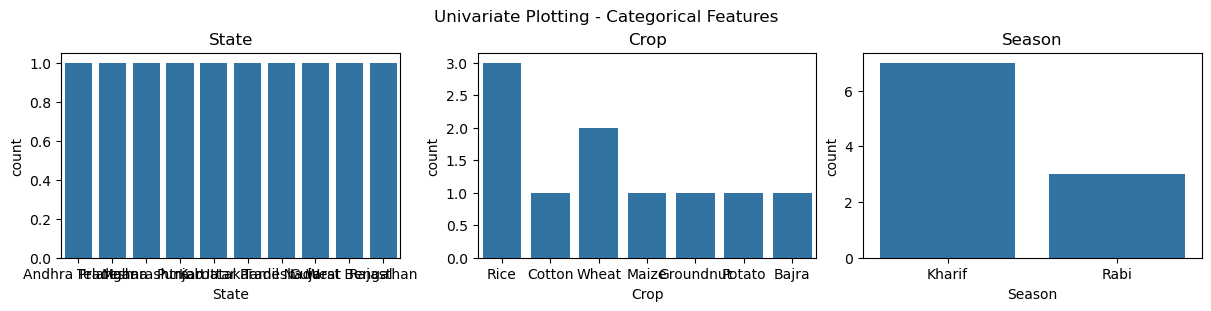

In [39]:
# Univariate - Categorical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Categorical Features")

axs[0].set_title("State")
sns.countplot(data=df, x='State', ax=axs[0])

axs[1].set_title("Crop")
sns.countplot(data=df, x='Crop', ax=axs[1])

axs[2].set_title("Season")
sns.countplot(data=df, x='Season', ax=axs[2])

<Axes: title={'center': 'Seed_Variety'}, xlabel='Seed_Variety', ylabel='count'>

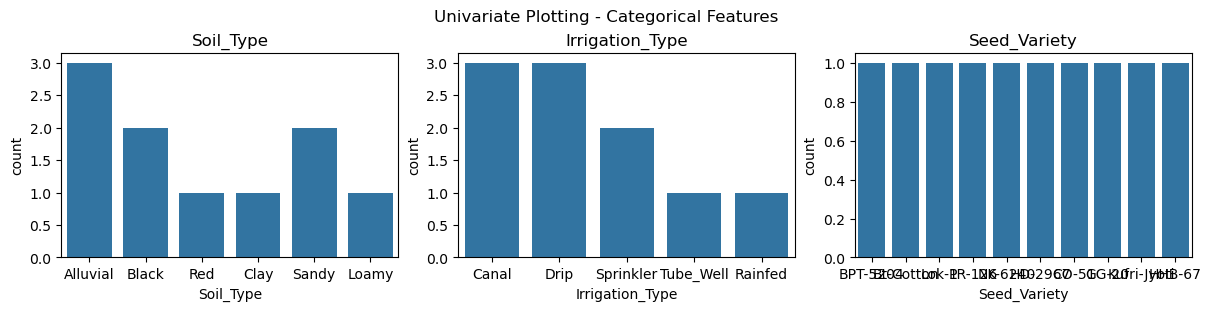

In [40]:
# Univariate - Categorical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Categorical Features")

axs[0].set_title("Soil_Type")
sns.countplot(data=df, x='Soil_Type', ax=axs[0])

axs[1].set_title("Irrigation_Type")
sns.countplot(data=df, x='Irrigation_Type', ax=axs[1])

axs[2].set_title("Seed_Variety")
sns.countplot(data=df, x='Seed_Variety', ax=axs[2])

<Axes: title={'center': 'Crop_Disease_Status'}, xlabel='Crop_Disease_Status', ylabel='count'>

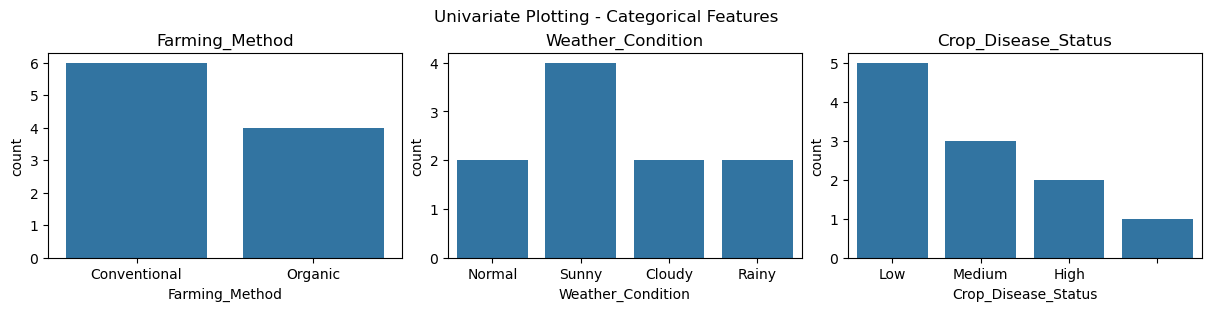

In [41]:
# Univariate - Categorical Analysis

fig, axs = plt.subplots(1, 3, figsize=(12, 3), constrained_layout=True)
fig.suptitle("Univariate Plotting - Categorical Features")

axs[0].set_title("Farming_Method")
sns.countplot(data=df, x='Farming_Method', ax=axs[0])

axs[1].set_title("Weather_Condition")
sns.countplot(data=df, x='Weather_Condition', ax=axs[1])

axs[2].set_title("Crop_Disease_Status")
sns.countplot(data=df, x='Crop_Disease_Status', ax=axs[2])

# Segregrate Inputs and Output

In [42]:
# Define the predictors (X) and target variable (y)

X = df.drop(columns=['Yield_ton_per_hectare'])

y = df['Yield_ton_per_hectare']

# Split the Data into Train and Test

In [43]:
# Split into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.25, 
                                                    random_state = 0)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(9, 19) (9,)
(4, 19) (4,)


# Apply Data Preparation on Training Data

In [44]:
X_train.dtypes

State                   object
Crop                    object
Season                  object
Soil_Type               object
Irrigation_Type         object
Seed_Variety            object
Farming_Method          object
Weather_Condition       object
Crop_Disease_Status     object
Area_Hectare           float64
Rainfall_mm            float64
Temperature_C          float64
Humidity_%             float64
Soil_pH                float64
Soil_Moisture_%        float64
Fertilizer_kg          float64
Pesticide_kg           float64
Irrigation_Water_mm    float64
Sunshine_Hours         float64
dtype: object

In [45]:
# Separating Categorical and Numerical Columns

X_train_cat = X_train.select_dtypes(include=['object'])
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])

In [46]:
X_train_cat.head()

,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status
2,Maharashtra,Wheat,Rabi,Black,Drip,Lok-1,Conventional,Cloudy,Low
8,West Bengal,Potato,Rabi,Loamy,Sprinkler,Kufri-Jyoti,Conventional,Cloudy,Medium
1,Telangana,Cotton,Kharif,Black,Drip,Bt-Cotton,Organic,Sunny,Medium
7,Gujarat,Groundnut,Kharif,Sandy,Drip,GG-20,Conventional,Sunny,High
9,Rajasthan,Bajra,Kharif,Sandy,Rainfed,HHB-67,Organic,Sunny,High


In [47]:
X_train_num.head()

,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours
2,1100.0,680.0,25.4,62.0,6.8,25.0,175.0,9.0,300.0,7.8
8,800.0,1050.0,23.9,76.0,6.1,34.0,170.0,10.0,360.0,6.8
1,950.0,720.0,29.2,70.0,7.1,28.0,160.0,10.0,350.0,8.1
7,900.0,610.0,30.1,65.0,7.3,22.0,145.0,7.0,290.0,8.4
9,1050.0,480.0,31.5,48.0,7.5,18.0,135.0,6.0,180.0,9.0


In [48]:
# Rescaling numerical features
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

# column names are (annoyingly) lost after Scaling
# (i.e. the dataframe is converted to a numpy ndarray)
X_train_num_transformed = pd.DataFrame(minmax_scaler.fit_transform(X_train_num), 
                                    columns = minmax_scaler.get_feature_names_out(), 
                                    index = X_train_num.index)

X_train_num_transformed.head()

,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours
2,0.500000,0.350877,0.197368,0.424242,0.500000,0.411765,0.727273,0.428571,0.444444,0.454545
8,0.000000,1.000000,0.000000,0.848485,0.000000,0.941176,0.636364,0.571429,0.666667,0.000000
1,0.250000,0.421053,0.697368,0.666667,0.714286,0.588235,0.454545,0.571429,0.629630,0.590909
7,0.166667,0.228070,0.815789,0.515152,0.857143,0.235294,0.181818,0.142857,0.407407,0.727273
9,0.416667,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [49]:
# Let's now analyse the properties of 'minmax_scaler'

print("Number of Numerical Features:", minmax_scaler.n_features_in_)
print("Output Feature Names:", minmax_scaler.get_feature_names_out())
print("Minimum of each column:", minmax_scaler.data_min_)
print("Maximum of each column:", minmax_scaler.data_max_)

Number of Numerical Features: 10
Output Feature Names: ['Area_Hectare' 'Rainfall_mm' 'Temperature_C' 'Humidity_%' 'Soil_pH'
 'Soil_Moisture_%' 'Fertilizer_kg' 'Pesticide_kg' 'Irrigation_Water_mm'
 'Sunshine_Hours']
Minimum of each column: [800.  480.   23.9  48.    6.1  18.  135.    6.  180.    6.8]
Maximum of each column: [1400.  1050.    31.5   81.     7.5   35.   190.    13.   450.     9. ]


In [50]:
# Let's also describe the transformed data statistics

X_train_num_transformed.describe().round(2)

,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours
count,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00,8.00
mean,0.49,0.46,0.49,0.59,0.55,0.54,0.59,0.54,0.57,0.42
std,0.35,0.32,0.36,0.34,0.32,0.36,0.35,0.34,0.31,0.35
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.23,0.27,0.18,0.40,0.39,0.32,0.39,0.36,0.44,0.15
50%,0.46,0.39,0.56,0.59,0.57,0.50,0.68,0.57,0.57,0.41
75%,0.73,0.68,0.73,0.86,0.75,0.85,0.84,0.75,0.72,0.62
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [51]:
# OneHotEncoding the categorical features
from sklearn.preprocessing import OneHotEncoder

onehot_encoder = OneHotEncoder(sparse_output=False, 
                               handle_unknown="ignore")

# column names are (annoyingly) lost after OneHotEncoding
# (i.e. the dataframe is converted to a numpy ndarray)
X_train_cat_tansformed = pd.DataFrame(onehot_encoder.fit_transform(X_train_cat), 
                               columns=onehot_encoder.get_feature_names_out(), 
                               index = X_train_cat.index)

print("Shape of Data before Transformation:", X_train_cat.shape)
print("Shape of Data after Transformation:", X_train_cat_tansformed.shape)

X_train_cat_tansformed.head()

Shape of Data before Transformation: (9, 9)
Shape of Data after Transformation: (9, 51)


,State_Andhra Pradesh,State_Gujarat,State_Maharashtra,State_Punjab,State_Rajasthan,State_Telangana,State_Uttar Pradesh,State_West Bengal,State_nan,Crop_Bajra,...,Farming_Method_nan,Weather_Condition_Cloudy,Weather_Condition_Normal,Weather_Condition_Rainy,Weather_Condition_Sunny,Weather_Condition_nan,Crop_Disease_Status_,Crop_Disease_Status_High,Crop_Disease_Status_Low,Crop_Disease_Status_Medium
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
9,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [52]:
# Let's now analyse the properties of 'onehot_encoder'

print("Applied encoding on:", onehot_encoder.feature_names_in_)
print("Unique Categories:", onehot_encoder.categories_)
print("Feature Names after encoding:", onehot_encoder.get_feature_names_out())

Applied encoding on: ['State' 'Crop' 'Season' 'Soil_Type' 'Irrigation_Type' 'Seed_Variety'
 'Farming_Method' 'Weather_Condition' 'Crop_Disease_Status']
Unique Categories: [array(['Andhra Pradesh', 'Gujarat', 'Maharashtra', 'Punjab', 'Rajasthan',
       'Telangana', 'Uttar Pradesh', 'West Bengal', nan], dtype=object), array(['Bajra', 'Cotton', 'Groundnut', 'Potato', 'Rice', 'Wheat', nan],
      dtype=object), array(['Kharif', 'Rabi', nan], dtype=object), array(['Alluvial', 'Black', 'Loamy', 'Sandy', nan], dtype=object), array(['Canal', 'Drip', 'Rainfed', 'Sprinkler', 'Tube_Well', nan],
      dtype=object), array(['BPT-5204', 'Bt-Cotton', 'GG-20', 'HD-2967', 'HHB-67',
       'Kufri-Jyoti', 'Lok-1', 'PR-126', nan], dtype=object), array(['Conventional', 'Organic', nan], dtype=object), array(['Cloudy', 'Normal', 'Rainy', 'Sunny', nan], dtype=object), array([' ', 'High', 'Low', 'Medium'], dtype=object)]
Feature Names after encoding: ['State_Andhra Pradesh' 'State_Gujarat' 'State_Maharashtra'

In [54]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

# Create OrdinalEncoder
ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    encoded_missing_value=-5
)

# Transform categorical training data
X_train_cat_transformed = pd.DataFrame(
    ordinal_encoder.fit_transform(X_train_cat),
    columns=ordinal_encoder.get_feature_names_out(),
    index=X_train_cat.index
)

# Display the encoded data as a table
X_train_cat_transformed.head()

,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status
2,2.0,5.0,1.0,1.0,1.0,6.0,0.0,0.0,2.0
8,7.0,3.0,1.0,2.0,3.0,5.0,0.0,0.0,3.0
1,5.0,1.0,0.0,1.0,1.0,1.0,1.0,3.0,3.0
7,1.0,2.0,0.0,3.0,1.0,2.0,0.0,3.0,1.0
9,4.0,0.0,0.0,3.0,2.0,4.0,1.0,3.0,1.0


#### Concatinate X_train_num_transformed and X_train_cat_transformed

In [55]:
X_train_transformed = pd.concat([X_train_num_transformed, X_train_cat_transformed], axis=1)

X_train_transformed.head()

,Area_Hectare,Rainfall_mm,Temperature_C,Humidity_%,Soil_pH,Soil_Moisture_%,Fertilizer_kg,Pesticide_kg,Irrigation_Water_mm,Sunshine_Hours,State,Crop,Season,Soil_Type,Irrigation_Type,Seed_Variety,Farming_Method,Weather_Condition,Crop_Disease_Status
2,0.500000,0.350877,0.197368,0.424242,0.500000,0.411765,0.727273,0.428571,0.444444,0.454545,2.0,5.0,1.0,1.0,1.0,6.0,0.0,0.0,2.0
8,0.000000,1.000000,0.000000,0.848485,0.000000,0.941176,0.636364,0.571429,0.666667,0.000000,7.0,3.0,1.0,2.0,3.0,5.0,0.0,0.0,3.0
1,0.250000,0.421053,0.697368,0.666667,0.714286,0.588235,0.454545,0.571429,0.629630,0.590909,5.0,1.0,0.0,1.0,1.0,1.0,1.0,3.0,3.0
7,0.166667,0.228070,0.815789,0.515152,0.857143,0.235294,0.181818,0.142857,0.407407,0.727273,1.0,2.0,0.0,3.0,1.0,2.0,0.0,3.0,1.0
9,0.416667,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.0,0.0,0.0,3.0,2.0,4.0,1.0,3.0,1.0


# Apply Data Preparation on Test Data

In [81]:
# Separate Categorical and Numerical Features

X_test_cat = X_test.select_dtypes(include=['object'])
X_test_num = X_test.select_dtypes(include=['int64', 'float64'])

AttributeError: 'numpy.ndarray' object has no attribute 'select_dtypes'